In [ ]:
!pip install pulp
import pandas as pd
import pulp
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

##Работа с картой оригинального датасета

In [ ]:
df_original = pd.read_csv('prepared_dataset.txt', delimiter='№', engine="python")
df_original.head()

,id,word,transcription,gender,url
0,1,aardvark,ˈɑːdˌvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...
1,2,aaron,ˈɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...
2,3,aaron,ˈɛərən,женщина,https://audio12.forvo.com/audios/mp3/l/9/l9_93...
3,4,aaronic,ɛəˈrɒnɪk,мужчина,https://audio12.forvo.com/audios/mp3/7/8/78_89...
4,5,abaca,ˈæbəkə,мужчина,https://audio12.forvo.com/audios/mp3/2/o/2o_89...


In [ ]:
df_original_clean = df_original.copy()
df_original_clean['transcription'] = df_original_clean['transcription'].str.replace(r'[ˈˌ]', '', regex=True)
df_original_clean.head()

,id,word,transcription,gender,url
0,1,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...
1,2,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...
2,3,aaron,ɛərən,женщина,https://audio12.forvo.com/audios/mp3/l/9/l9_93...
3,4,aaronic,ɛərɒnɪk,мужчина,https://audio12.forvo.com/audios/mp3/7/8/78_89...
4,5,abaca,æbəkə,мужчина,https://audio12.forvo.com/audios/mp3/2/o/2o_89...


In [ ]:
original_path_column = [f'audios/{id}.wav' for id in df_original['id']]
df_original_clean['path'] = original_path_column
df_original['path'] = original_path_column

##Работа с картой аугментированного датасета

In [ ]:
df_augmented_clean = pd.read_csv('augmented_dataset.txt', delimiter='№', engine="python")
df_augmented_clean.head()

,id,word,transcription,gender,url,path
0,0,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_0_c0_9438478_39_12928.mp3
1,1,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_1_c0_9438478_39_12928.mp3
2,2,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_2_c0_9438478_39_12928.mp3
3,3,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...,augmented_audios/aug_0_83_9410408_39_12931.mp3
4,4,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...,augmented_audios/aug_1_83_9410408_39_12931.mp3


In [ ]:
df_augmented_clean = df_augmented_clean.drop(['id'], axis=1)
df_augmented_clean = df_augmented_clean[(df_augmented_clean['gender'] == "мужчина") | (df_augmented_clean['gender'] == "женщина")]
df_augmented_clean.head()

,word,transcription,gender,url,path
0,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_0_c0_9438478_39_12928.mp3
1,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_1_c0_9438478_39_12928.mp3
2,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_2_c0_9438478_39_12928.mp3
3,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...,augmented_audios/aug_0_83_9410408_39_12931.mp3
4,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...,augmented_audios/aug_1_83_9410408_39_12931.mp3


##Формируем списки семплов для дальнейшей балансировки

In [ ]:
unary_phonemes_list = [
    "æ","ɪ", "ɛ", "ɒ", "ʊ", "ʌ", "ə",
    "p", "f", "t", "θ", "s", "ʃ", "k", "b", "v", "d", "ð", "z", "ʒ", "ɡ", "h", "m", "n", "ŋ", "r", "l", "w", "j"
]
binary_phonemes_list = [
    "ɑː", "iː", "ɔː", "uː", "ɜː",
    "eɪ", "aɪ", "aʊ", "əʊ", "ɔɪ", "ɪə", "ɛə", "ʊə",
    "tʃ", "dʒ"
]
tokens = unary_phonemes_list + binary_phonemes_list
assert(len(tokens) == 44)

In [ ]:
original_cleaned_samples = []
for word, transcription, gender, url, path in zip(df_original_clean['word'],
                                                  df_original_clean['transcription'],
                                                  df_original_clean['gender'],
                                                  df_original_clean['url'],
                                                  df_original_clean['path']):
  transcription_tokens = []
  i = 0
  while i < len(transcription):
    if i < len(transcription) - 1 and transcription[i:i+2] in binary_phonemes_list:
      transcription_tokens += [transcription[i:i+2]]
      i+=2
    else:
      transcription_tokens += [transcription[i]]
      i+=1
  original_cleaned_samples += [{'word': word,
                                'tokens': transcription_tokens,
                                'gender': 'male' if gender == 'мужчина' else 'female',
                                'url': url,
                                'path': path}]

In [ ]:
cleaned_samples_to_add = []
for word, transcription, gender, url, path in zip(df_augmented_clean['word'],
                                                  df_augmented_clean['transcription'],
                                                  df_augmented_clean['gender'],
                                                  df_augmented_clean['url'],
                                                  df_augmented_clean['path']):
  transcription_tokens = []
  i = 0
  while i < len(transcription):
    if i < len(transcription) - 1 and transcription[i:i+2] in binary_phonemes_list:
      transcription_tokens += [transcription[i:i+2]]
      i+=2
    else:
      transcription_tokens += [transcription[i]]
      i+=1
  cleaned_samples_to_add += [{'word': word,
                              'tokens': transcription_tokens,
                              'gender': 'male' if gender == 'мужчина' else 'female',
                              'url': url,
                              'path': path}]

In [ ]:
male_count = 0
female_count = 0
for sample in cleaned_samples_to_add:
  if sample['gender'] == 'male':
    male_count += 1
  else:
    female_count += 1
print(male_count, female_count)

46656 62612


##Задача математического программирования (балансировка по токенам и полу)

In [ ]:
def GetIncludeExclude(tokens, original_samples, samples_to_add):
  N_target = 7500
  token_curr_counts = {} # относится к датасету, к которому мы добавляем
  for token in tokens:
    token_curr_counts[token] = {'total': 0, 'male': 0, 'female': 0}

  for sample in original_samples:
    for token in sample['tokens']:
      token_curr_counts[token]['total'] += 1
      token_curr_counts[token][sample['gender']] += 1
  model = pulp.LpProblem("Dataset_Balancing", pulp.LpMinimize)
  x_add = [pulp.LpVariable(f"x_add_{j}", cat="Binary") for j in range(len(samples_to_add))]
  x_remove = [pulp.LpVariable(f"x_remove_{k}", cat="Binary") for k in range(len(original_samples))]
  d_plus = {t: pulp.LpVariable(f"d_plus_{t}", lowBound=0) for t in tokens}
  d_minus = {t: pulp.LpVariable(f"d_minus_{t}", lowBound=0) for t in tokens}
  u = {t: pulp.LpVariable(f"u_{t}", lowBound=0) for t in tokens}
  v = {t: pulp.LpVariable(f"v_{t}", lowBound=0) for t in tokens}
  alpha = 10  # Вес баланса по количеству
  beta = 1   # Вес баланса по полу
  model += (
      alpha * pulp.lpSum([d_plus[t] + d_minus[t] for t in tokens]) +
      beta * pulp.lpSum([u[t] + v[t] for t in tokens])
  )
  for t in tokens:
    sum_add = pulp.lpSum([
        x_add[j] for j, sample in enumerate(samples_to_add)
        if t in sample["tokens"]
    ])
    sum_remove = pulp.lpSum([
        x_remove[k] for k, sample in enumerate(original_samples)
        if t in sample["tokens"]
    ])
    model += (
        token_curr_counts[t]["total"] + sum_add - sum_remove + d_minus[t] - d_plus[t] == N_target
    )
  for t in tokens:
    sum_add_male = pulp.lpSum([
        x_add[j] for j, sample in enumerate(samples_to_add)
        if t in sample["tokens"] and sample["gender"] == "male"
    ])
    sum_add_female = pulp.lpSum([
        x_add[j] for j, sample in enumerate(samples_to_add)
        if t in sample["tokens"] and sample["gender"] == "female"
    ])
    sum_remove_male = pulp.lpSum([
        x_remove[k] for k, sample in enumerate(original_samples)
        if t in sample["tokens"] and sample["gender"] == "male"
    ])
    sum_remove_female = pulp.lpSum([
        x_remove[k] for k, sample in enumerate(original_samples)
        if t in sample["tokens"] and sample["gender"] == "female"
    ])
    model += (
        (token_curr_counts[t]["male"] + sum_add_male - sum_remove_male) -
        (token_curr_counts[t]["female"] + sum_add_female - sum_remove_female) == u[t] - v[t]
    )
  model.solve()
  print("Status:", pulp.LpStatus[model.status])
  selected_to_add = [j for j in range(len(samples_to_add)) if x_add[j].value() == 1]
  selected_to_remove = [k for k in range(len(original_samples)) if x_remove[k].value() == 1]
  return selected_to_add, selected_to_remove

In [ ]:
samples_idx_to_add, samples_idx_to_remove = GetIncludeExclude(tokens, original_cleaned_samples, cleaned_samples_to_add)

print("Добавлено записей:", len(samples_idx_to_add))
print("Удалено записей:", len(samples_idx_to_remove))

Status: Optimal
Добавлено записей: 31788
Удалено записей: 13346


##Формируем новый сбалансированный датасет

In [ ]:
samples_idx_to_add = np.array(samples_idx_to_add, dtype=np.int32)
samples_idx_to_remove = np.array(samples_idx_to_remove, dtype=np.int32)

In [ ]:
original_samples_np = np.array(original_cleaned_samples, dtype=object)
samples_to_add_np = np.array(cleaned_samples_to_add, dtype=object)

In [ ]:
added_samples = samples_to_add_np[samples_idx_to_add]
mask_to_remain = np.ones_like(original_samples_np, dtype=bool)
mask_to_remain[samples_idx_to_remove] = False
remaining_samples = original_samples_np[mask_to_remain]
all_samples = np.concatenate([remaining_samples, added_samples])

##Оценка баланса до/после балансировки

In [ ]:
tokens_new_freq = {}
tokens_old_freq = {}
for t in tokens:
  tokens_new_freq[t] = 0
  tokens_old_freq[t] = 0

for sample in all_samples:
  for token in sample['tokens']:
    tokens_new_freq[token] += 1

for sample in original_samples_np:
  for token in sample['tokens']:
    tokens_old_freq[token] += 1

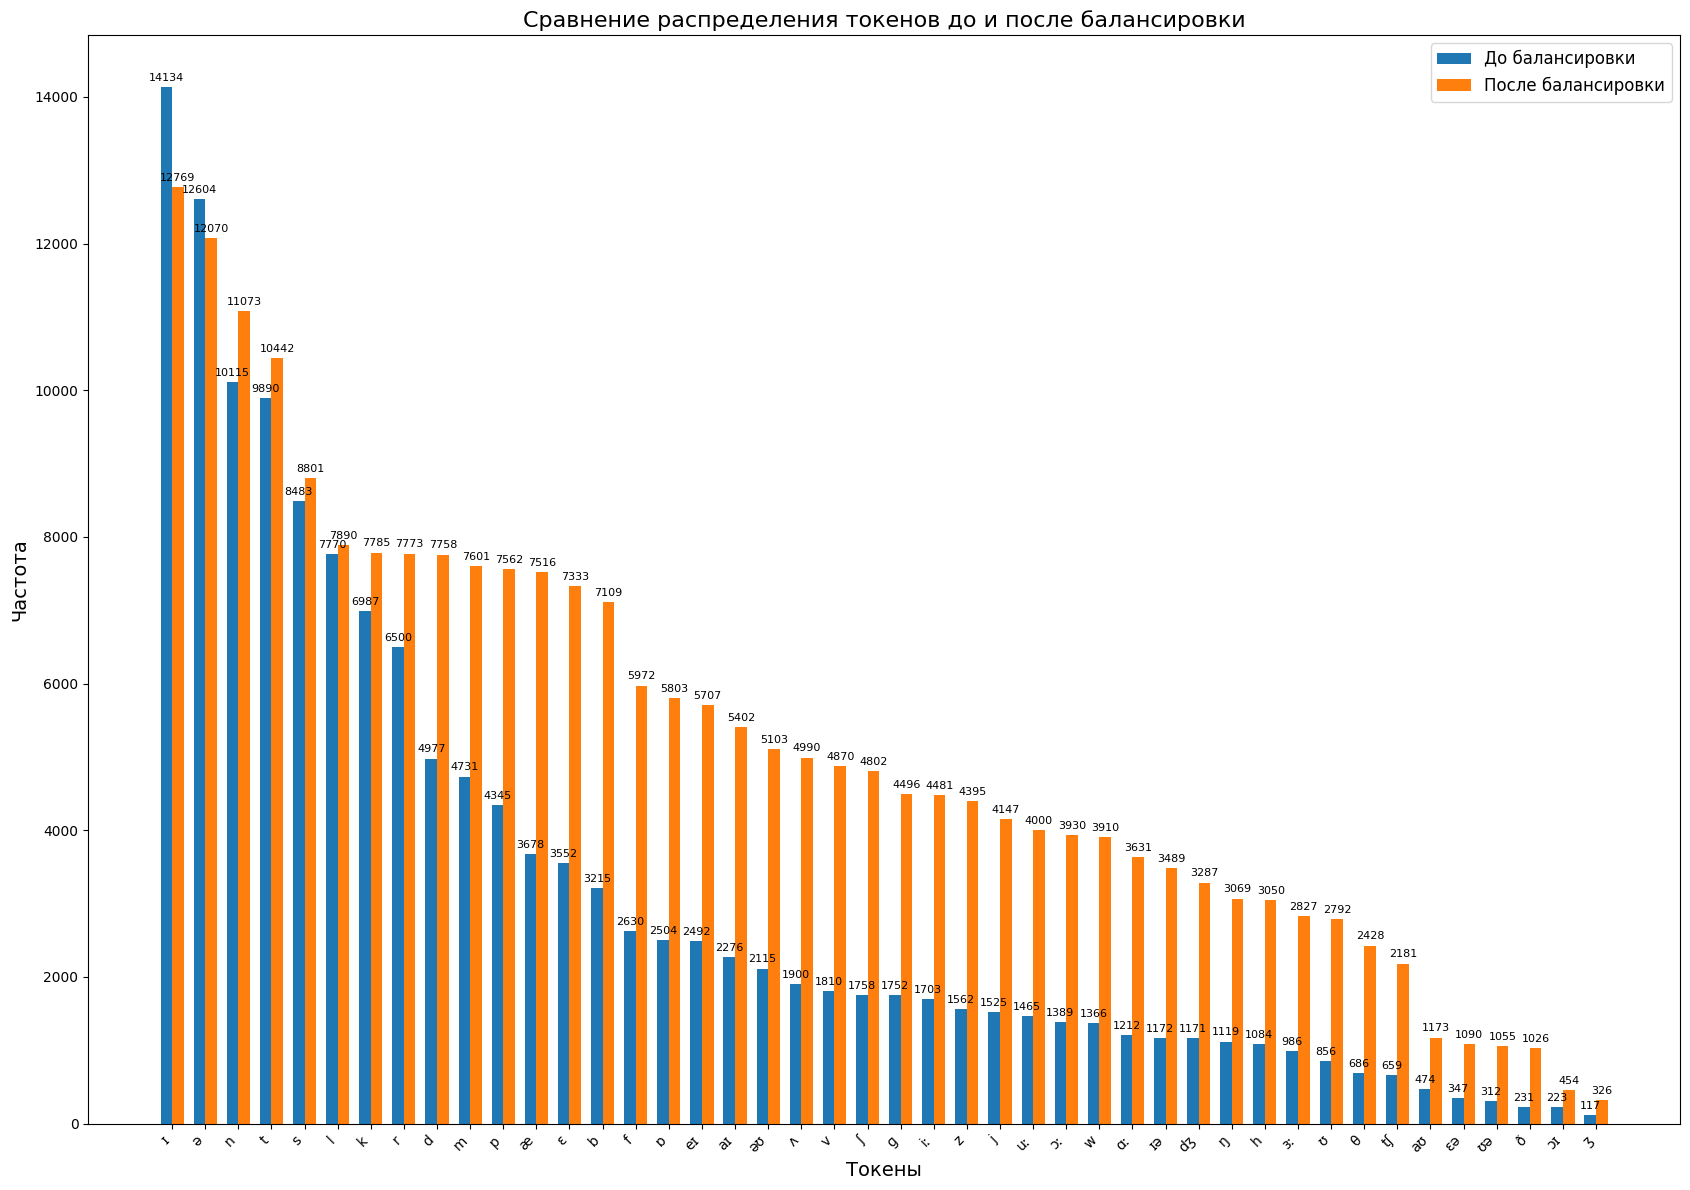

In [ ]:
phonemes_orig, frequencies_orig = zip(*tokens_old_freq.items())
frequencies_orig_sorted, phonemes_orig_sorted = zip(*sorted(zip(frequencies_orig, phonemes_orig), reverse=True))

phonemes_balanced, frequencies_balanced = zip(*tokens_new_freq.items())
frequencies_balanced_sorted, phonemes_balanced_sorted = zip(*sorted(zip(frequencies_balanced, phonemes_balanced), reverse=True))


fig, ax = plt.subplots(figsize=(17, 12))


bar_width = 0.35
index = np.arange(len(phonemes_orig_sorted))
x_labels = phonemes_orig_sorted


rects1 = ax.bar(index - bar_width/2, frequencies_orig_sorted, bar_width,
                label='До балансировки', color='#1f77b4')
rects2 = ax.bar(index + bar_width/2, frequencies_balanced_sorted, bar_width,
                label='После балансировки', color='#ff7f0e')


ax.set_title('Сравнение распределения токенов до и после балансировки', fontsize=16)
ax.set_xlabel('Токены', fontsize=14)
ax.set_ylabel('Частота', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.legend(fontsize=12)


def autolabel(rects):
    for rect in rects:
        height = int(rect.get_height())
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

##Вернём ударения в транскрипции

In [ ]:
words_transcriptions = {}
for word, transcription in zip(df_original['word'], df_original['transcription']):
  words_transcriptions[word] = transcription

In [ ]:
for sample in all_samples:
  if 'tokens' in sample:
    del sample['tokens']
  sample['path'] = sample['path'].split('.')[0] + '.wav'
  sample['transcription'] = words_transcriptions[sample['word']]

In [ ]:
with open('ready_map_for_trainingV1.txt', 'w', encoding='utf-8') as f:
  titles = "word№transcription№gender№url№path\n"
  f.write(titles)
  for sample in all_samples:
    f.write(f"{sample['word']}№{sample['transcription']}№{sample['gender']}№{sample['url']}№{sample['path']}\n")